## Star formation yellowbal PCA

### Alex Emert

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
from pyhere import here
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from ratio_function import RatioGenerator
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn import set_config

# make it work with data frames
set_config(transform_output="pandas")


In [87]:
phot = pd.read_csv(here("data/cleaned", "MIRION_cleaned_everything.csv"))
phot=phot.drop(columns=['YB'])
print(phot.head())

       DIAM         MASS          L_BOL         LM  TEMP  LRATIO  T_BOL  \
0  1.035301  2389.632608  126081.200100  52.761751  27.6   205.7  52.92   
1  0.160000    91.300000    3011.600000  32.985761  26.1     5.1  50.33   
2  0.178953   584.800838   25225.252860  43.134776  24.2   236.2  99.08   
3  0.136835    50.562165      96.046837   1.899579  16.9    19.7  24.83   
4  0.297600   846.910080   13722.157440  16.202614  21.3   108.1  53.23   

   SURF_DENS     F160     F250  ...     F24   e_F24       F70   e_F70  N8  \
0       0.59  439.180  268.570  ...     NaN     NaN       NaN  0.2450   5   
1       0.92  816.320  322.035  ...     NaN     NaN  488.7870  0.3700   5   
2       4.79  592.553  544.083  ...     NaN     NaN  794.7477  0.1517   5   
3       0.71   19.334   18.703  ...  2.5183  0.0442   22.0228  0.0971   5   
4       2.84  352.424  350.000  ...     NaN     NaN       NaN  0.1673   5   

   N12  N24  N70  f_MULTI  f_CEXT  
0    5    0    5        0       0  
1    5    0   

In [ ]:
flux_cols = ['F8', 'F12', 'F24', 'F70', 'F160', 'F250', 'F350', 'F500', 'F870', 'F1100']
flux_cols = flux_cols[::-1]
pca_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler()),
    ('pca', PCA())
])

pca_preprocessor = ColumnTransformer([
    ('pca_pipe', pca_pipe, flux_cols)
], remainder='passthrough')

phot_transformed = pca_preprocessor.fit_transform(phot)

In [89]:
phot_transformed.columns.tolist()

['pca_pipe__pca0',
 'pca_pipe__pca1',
 'pca_pipe__pca2',
 'pca_pipe__pca3',
 'pca_pipe__pca4',
 'pca_pipe__pca5',
 'pca_pipe__pca6',
 'pca_pipe__pca7',
 'pca_pipe__pca8',
 'pca_pipe__pca9',
 'remainder__DIAM',
 'remainder__MASS',
 'remainder__L_BOL',
 'remainder__LM',
 'remainder__TEMP',
 'remainder__LRATIO',
 'remainder__T_BOL',
 'remainder__SURF_DENS',
 'remainder__DIST',
 'remainder__e_F8',
 'remainder__e_F12',
 'remainder__e_F24',
 'remainder__e_F70',
 'remainder__N8',
 'remainder__N12',
 'remainder__N24',
 'remainder__N70',
 'remainder__f_MULTI',
 'remainder__f_CEXT']

In [74]:
p = 0.95
var_ratio = pca_preprocessor.named_transformers_['pca_pipe'].named_steps['pca'].explained_variance_ratio_

n_components = 1 + np.argmax(np.cumsum(var_ratio) >= p)
print("Optimal components (no ratio):", n_components)

Optimal components (no ratio): 7


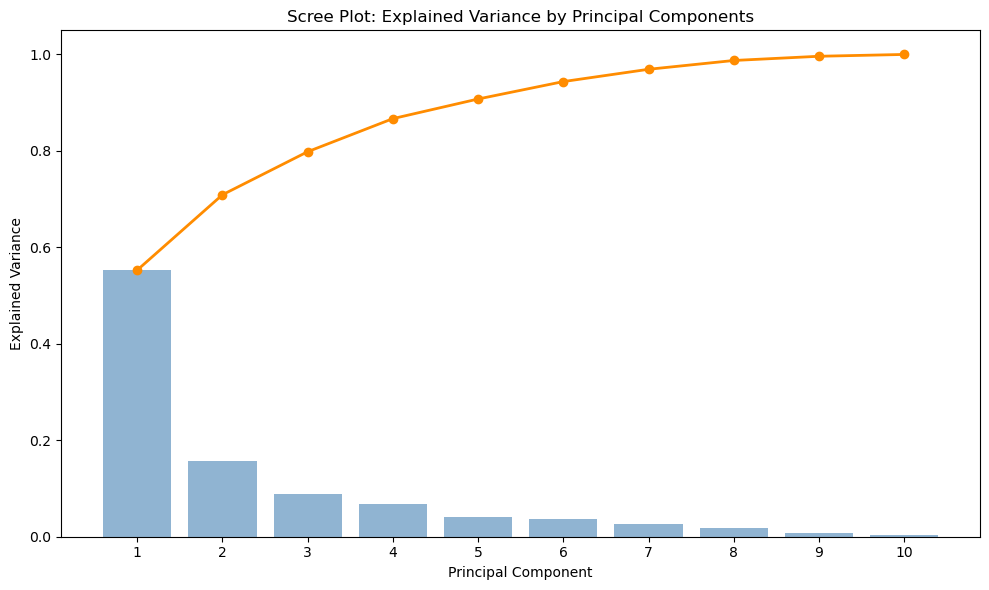

In [75]:
cum_var_ratio = np.cumsum(var_ratio)
    
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(var_ratio) + 1), var_ratio, alpha=0.6, align='center',
        label='Individual explained variance', color='steelblue')
plt.plot(range(1, len(cum_var_ratio) + 1), cum_var_ratio, 
             label='Cumulative explained variance', color='darkorange', 
             linewidth=2, marker='o')
plt.ylabel('Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot: Explained Variance by Principal Components')
plt.xticks(range(1, len(var_ratio) + 1))
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [62]:
len(phot_transformed.columns)

21

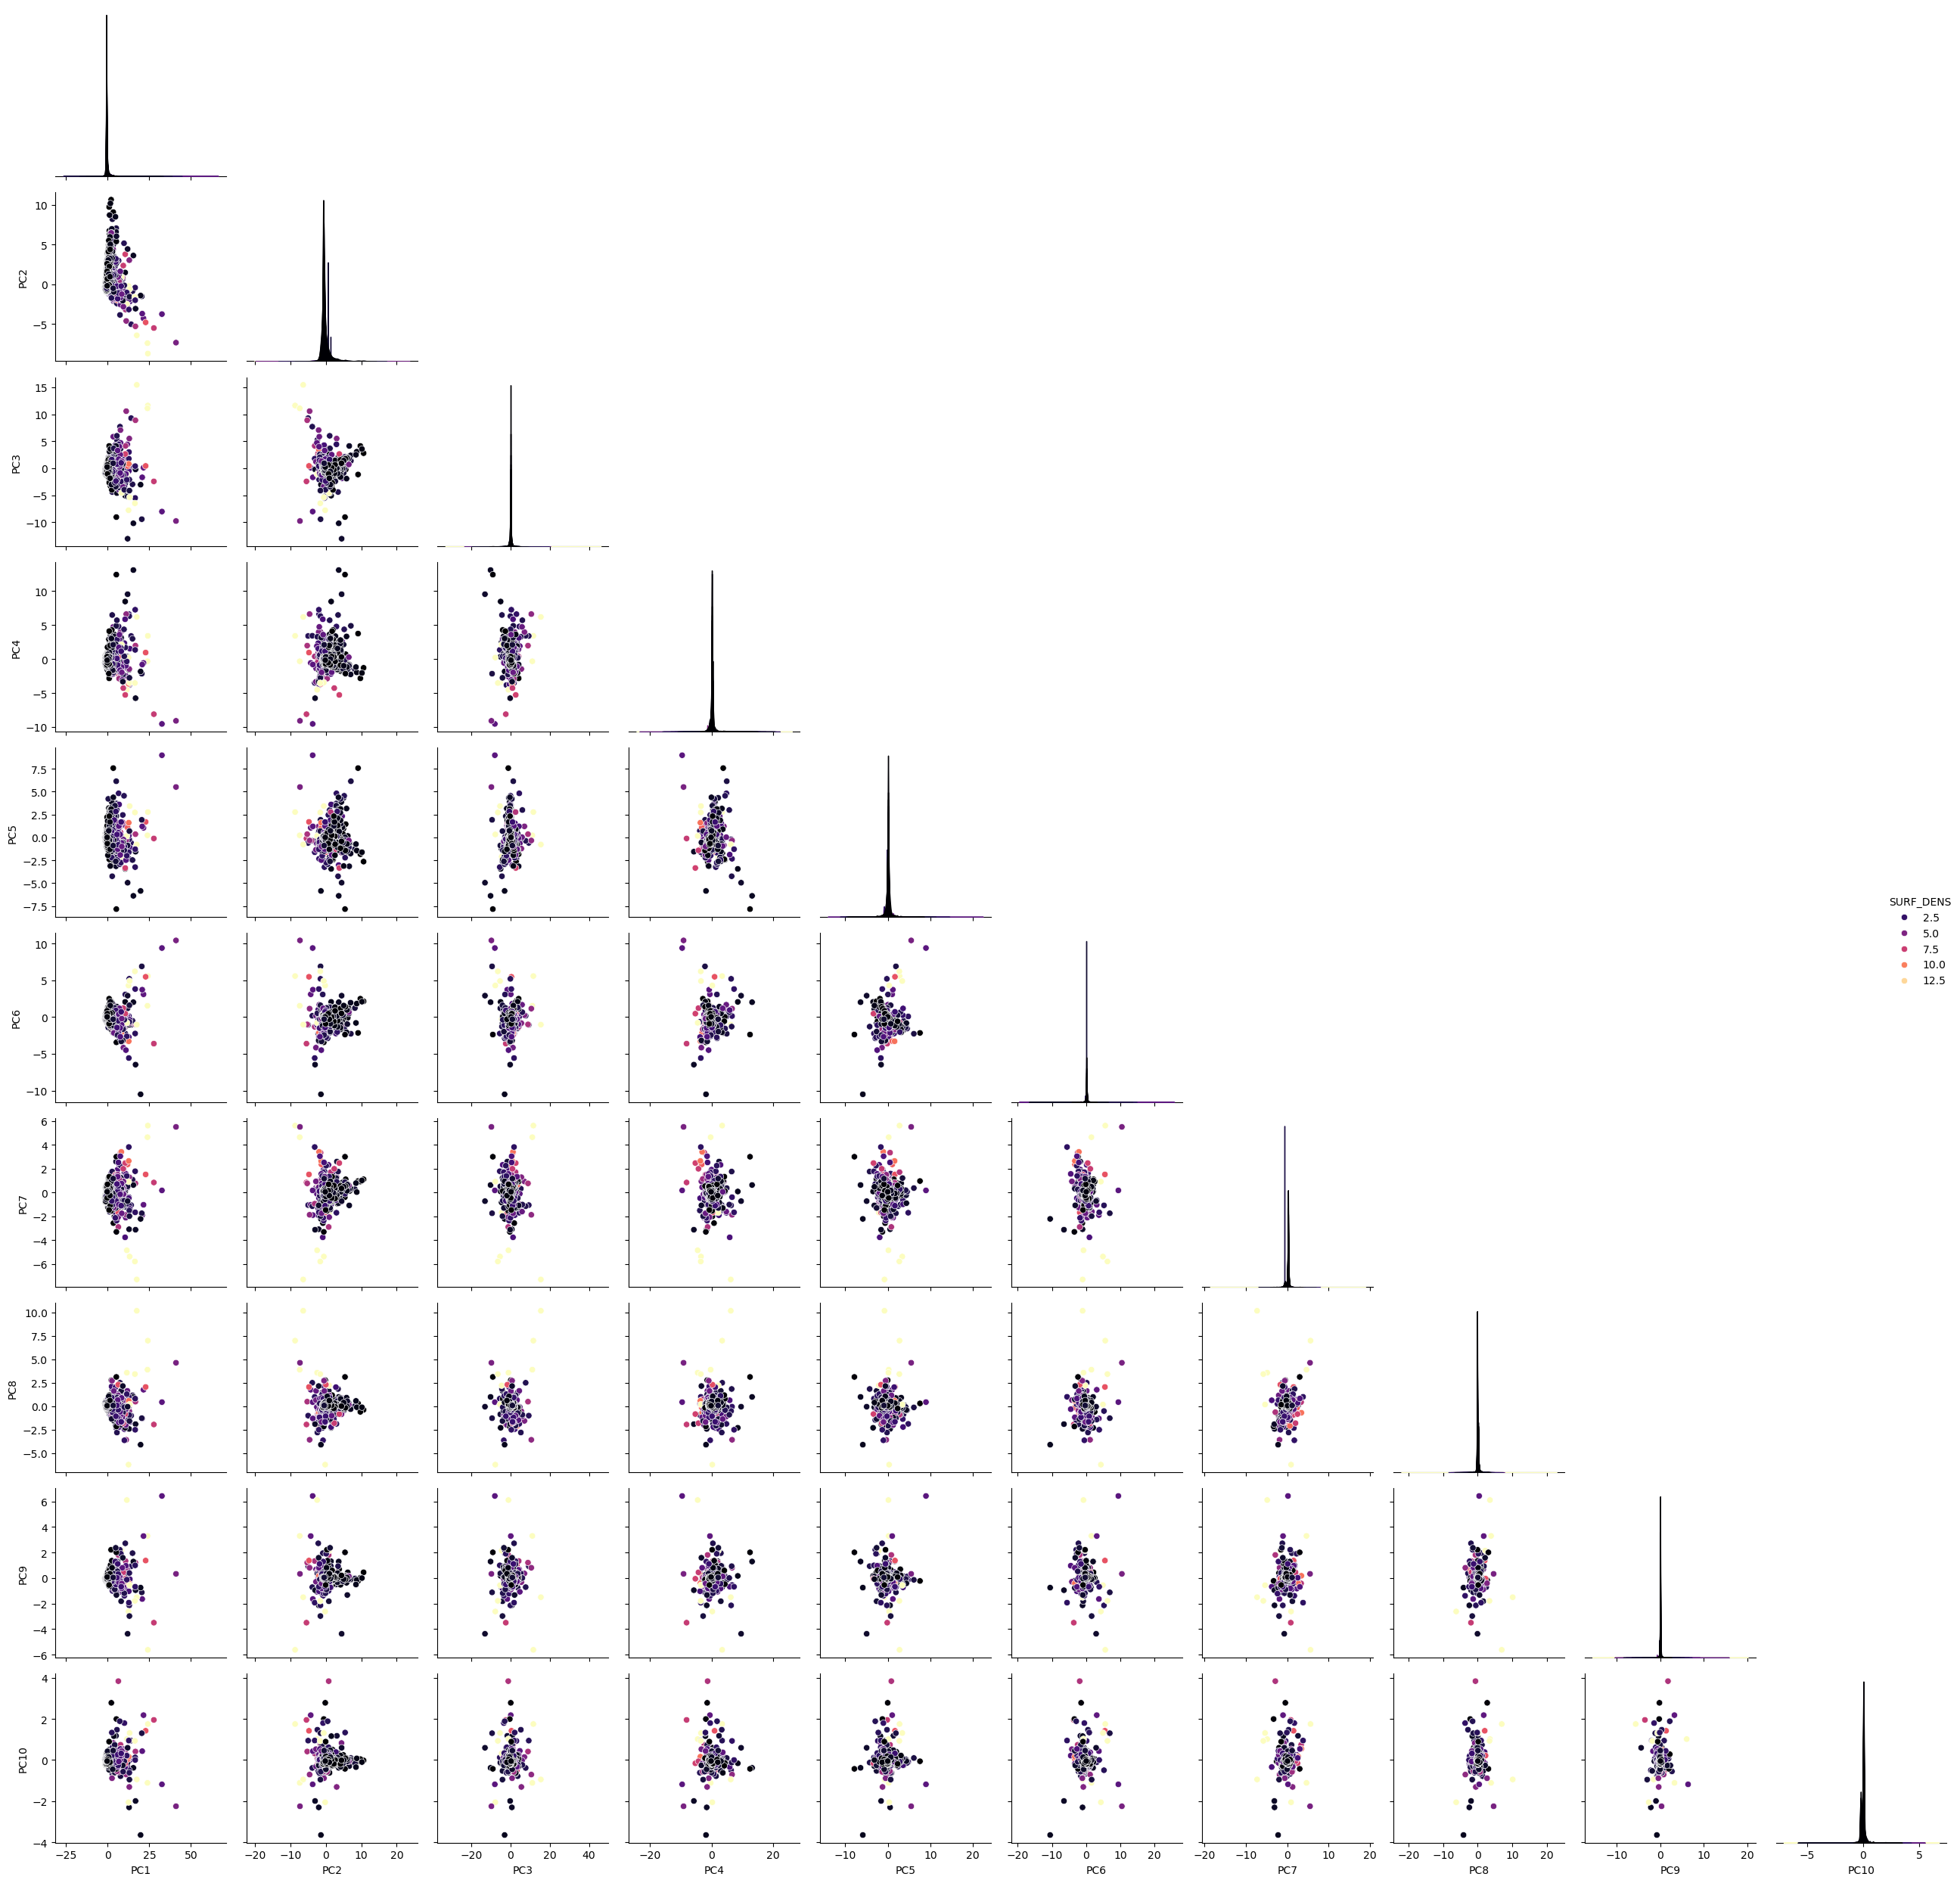

In [92]:
phot_transformed.columns = ['PC1', "PC2", 'PC3', 'PC4', "PC5", "PC6", 'PC7', 'PC8', 'PC9', "PC10",'DIAM', "MASS", "L_BOL", "LM", "TEMP", "LRATIO", "T_BOL", "SURF_DENS", "DIST", "e_F8", "e_F12", "e_F24", "e_F70", "N8", "N12", "N24", "N70", "f_MULTI", "f_CEXT"]
phot_pca_cols = phot_transformed.drop(columns=["DIST", "e_F8", "e_F12", "e_F24", "e_F70", "N8", "N12", "N24", "N70", "f_MULTI", "f_CEXT"])

surf_dens_df = phot_pca_cols.drop(columns=['DIAM', "MASS", "L_BOL", "LM", "TEMP", "LRATIO", "T_BOL"])
sns.pairplot(surf_dens_df, hue='SURF_DENS', palette='magma', corner=True)
plt.tight_layout()
plt.show()

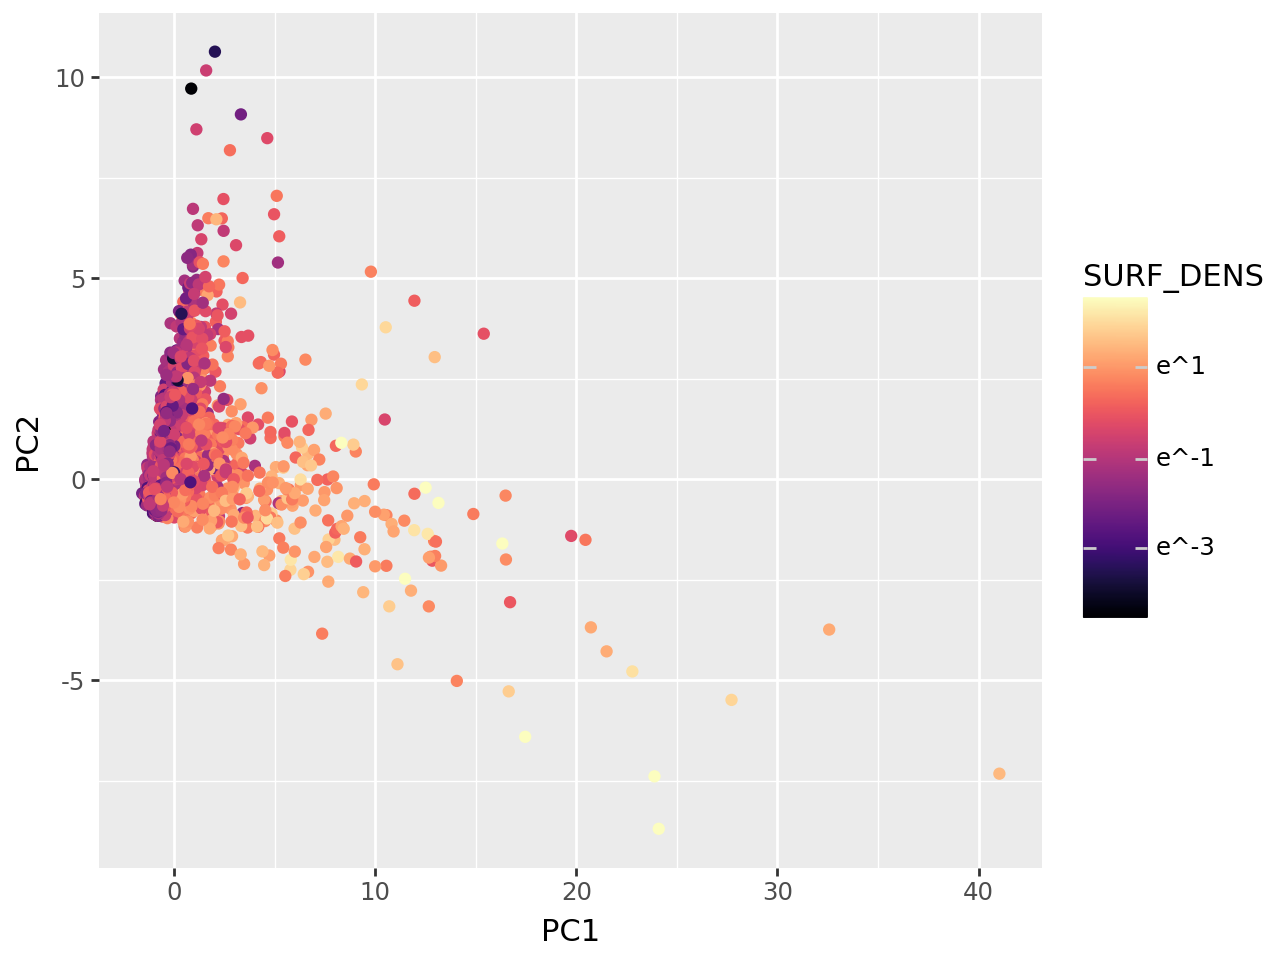

In [117]:
(
    ggplot(surf_dens_df, aes(x='PC1', y='PC2', color='SURF_DENS')) +
    geom_point() +
    scale_color_continuous(trans='log', cmap_name='magma')
)

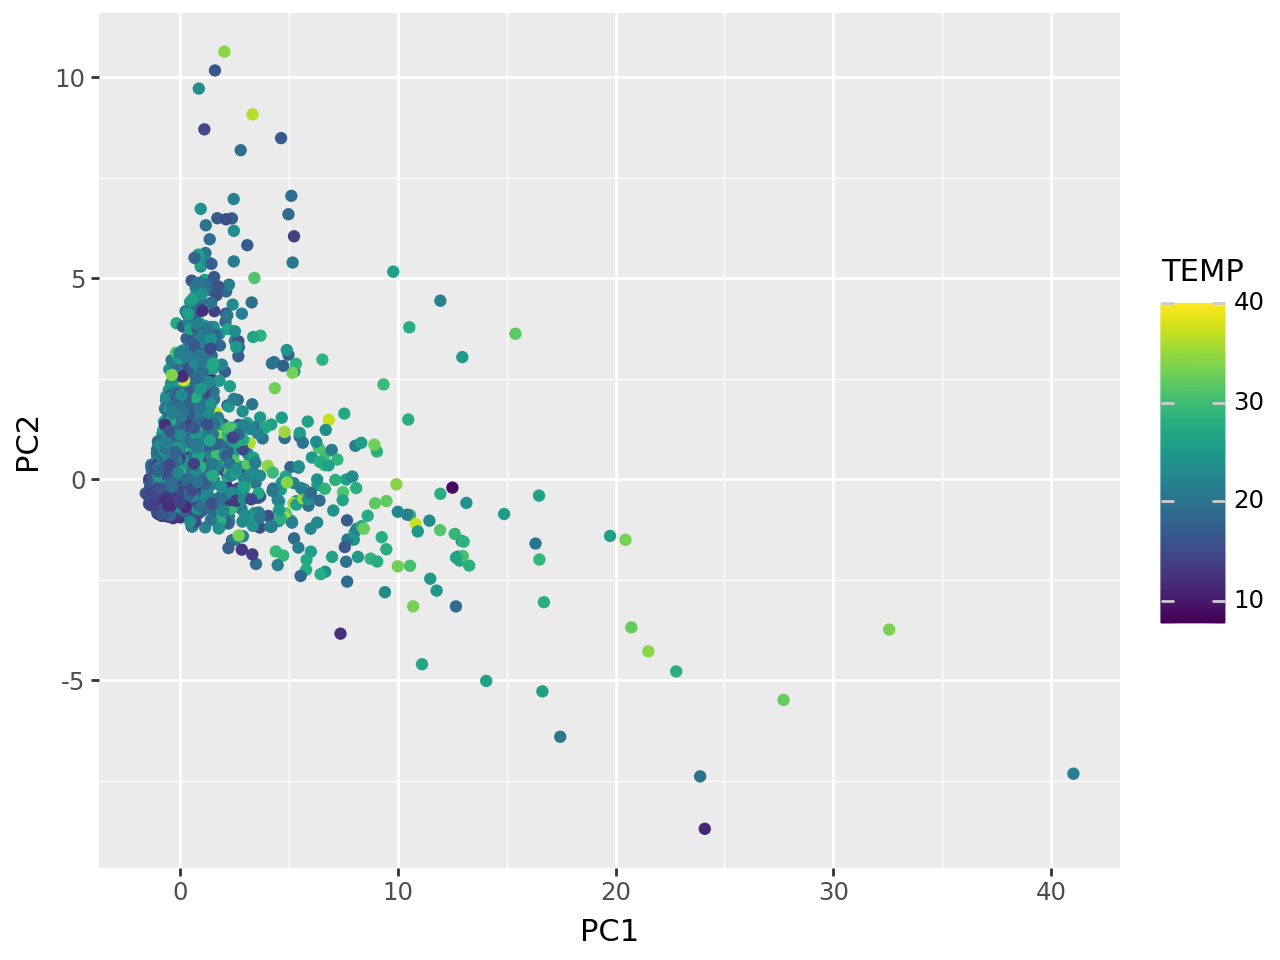

In [94]:
temp_df = phot_pca_cols.drop(columns=['DIAM', "MASS", "L_BOL", "LM", "SURF_DENS", "LRATIO", "T_BOL"])

(
    ggplot(temp_df, aes(x='PC1', y='PC2', color='TEMP')) +
    geom_point()
)

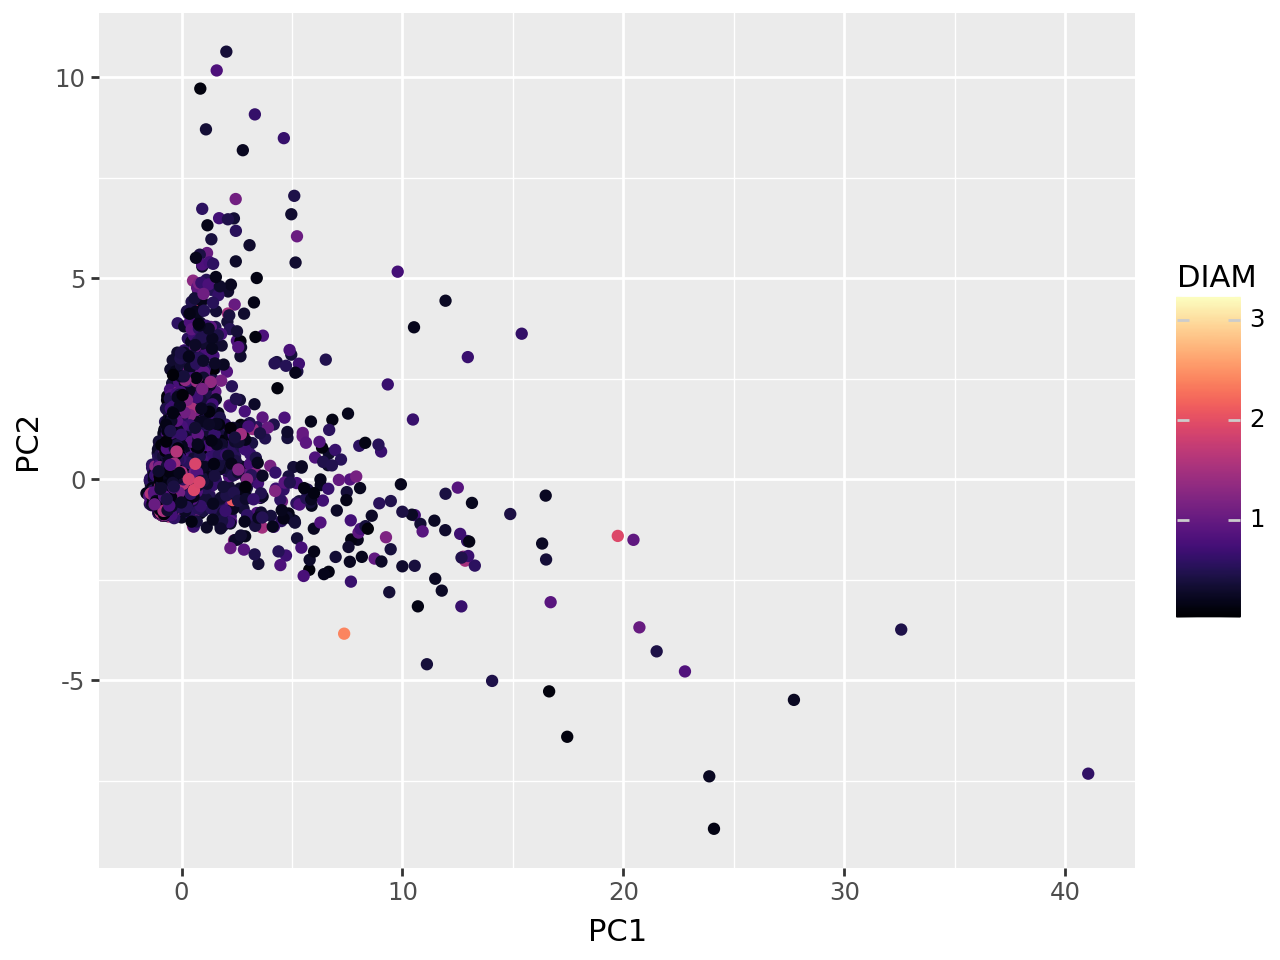

In [110]:
diam_df = phot_pca_cols.drop(columns=['TEMP', "MASS", "L_BOL", "LM", "SURF_DENS", "LRATIO", "T_BOL"])

(
    ggplot(diam_df, aes(x='PC1', y='PC2', color='DIAM')) +
    geom_point() +
    scale_color_cmap('magma')
)

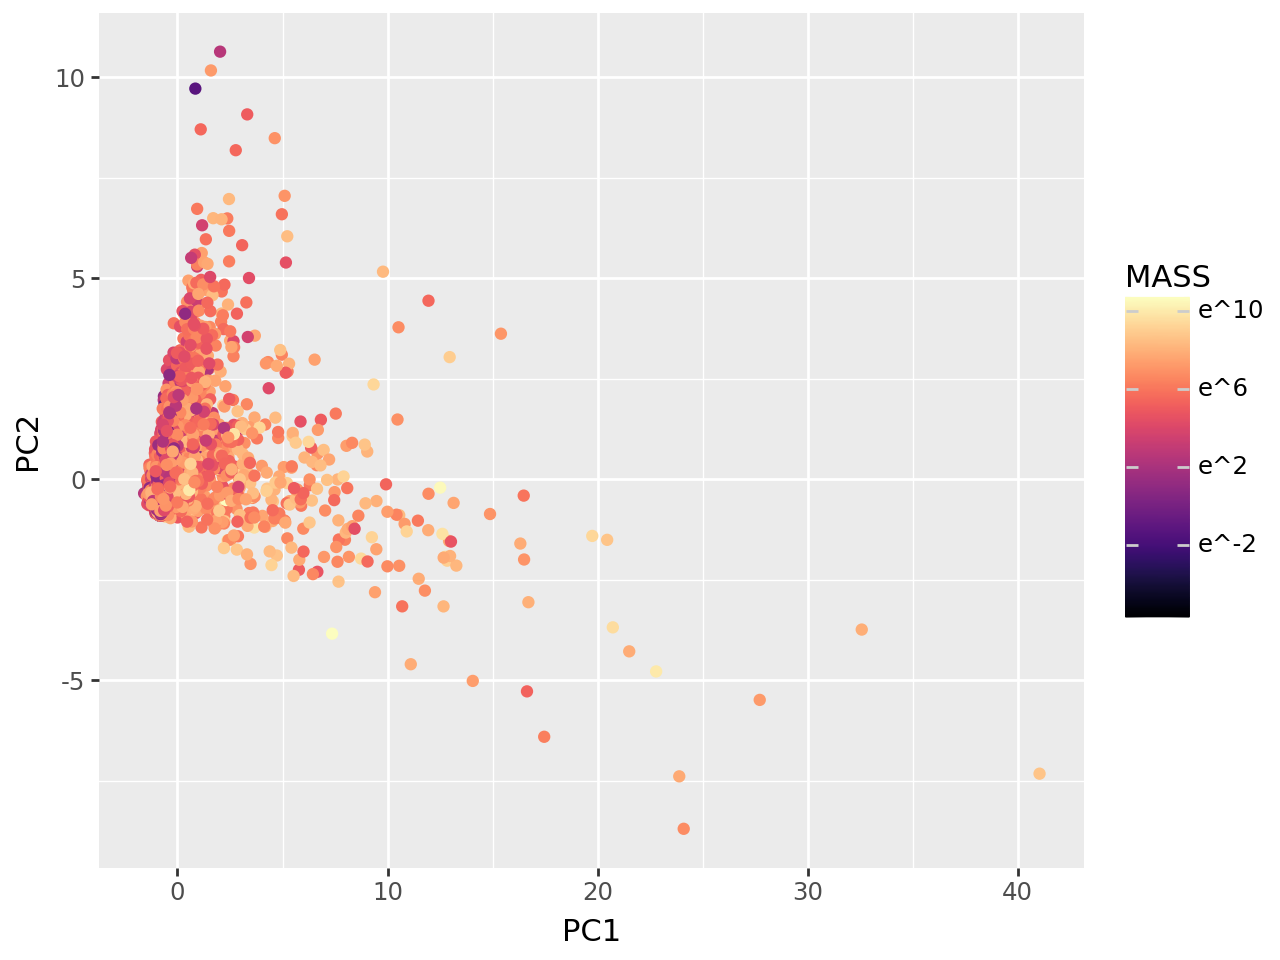

In [105]:
mass_df = phot_pca_cols.drop(columns=['TEMP', "DIAM", "L_BOL", "LM", "SURF_DENS", "LRATIO", "T_BOL"])

(
    ggplot(mass_df, aes(x='PC1', y='PC2', color='MASS')) +
    geom_point() +
    scale_color_continuous(trans='log', cmap_name='magma')
)

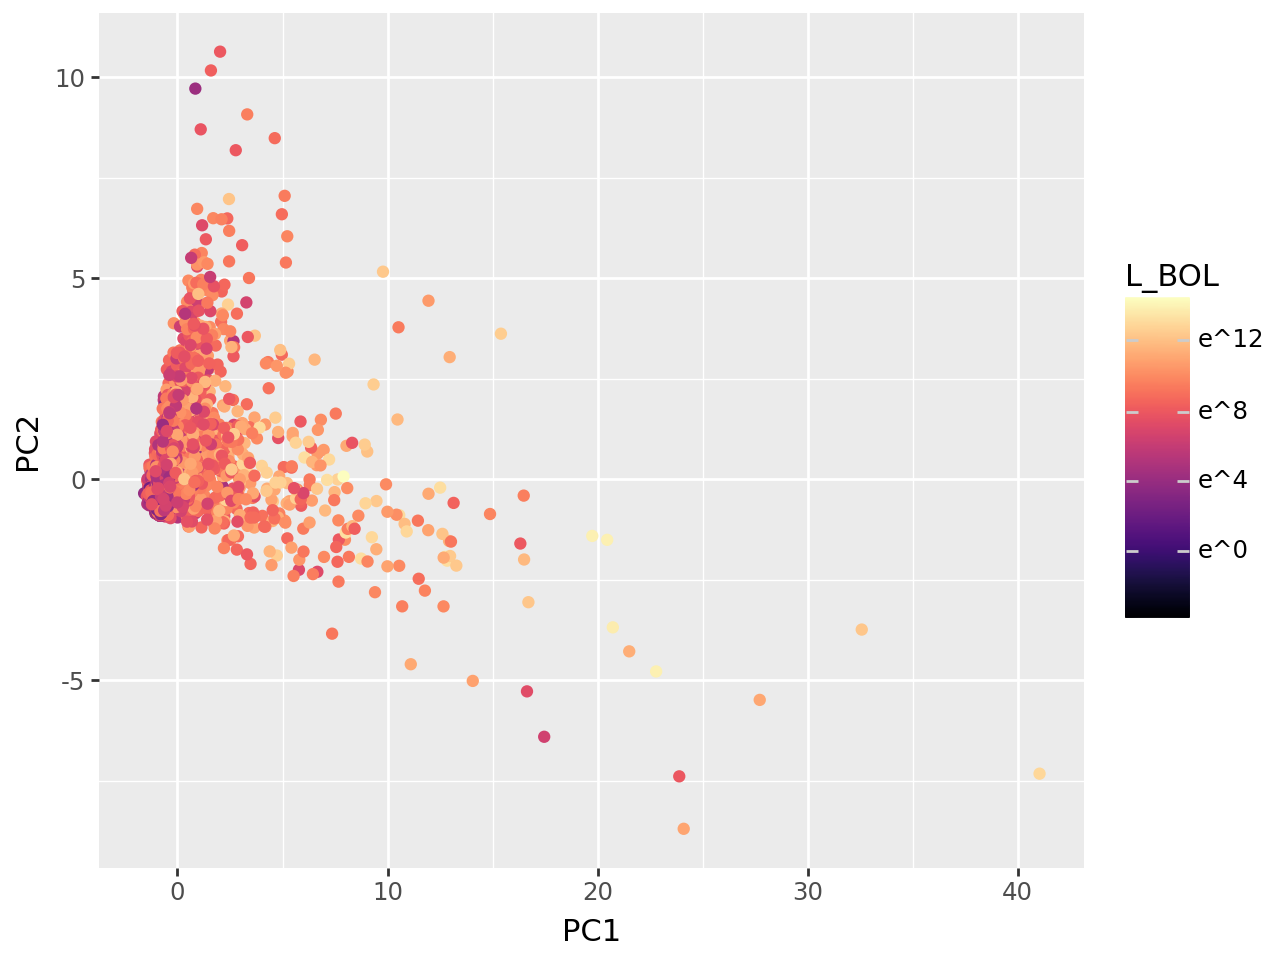

In [106]:
lbol_df = phot_pca_cols.drop(columns=['DIAM', "MASS", "TEMP", "LM", "SURF_DENS", "LRATIO", "T_BOL"])

(
    ggplot(lbol_df, aes(x='PC1', y='PC2', color='L_BOL')) +
    geom_point() +
    scale_color_continuous(trans='log', cmap_name='magma')
)

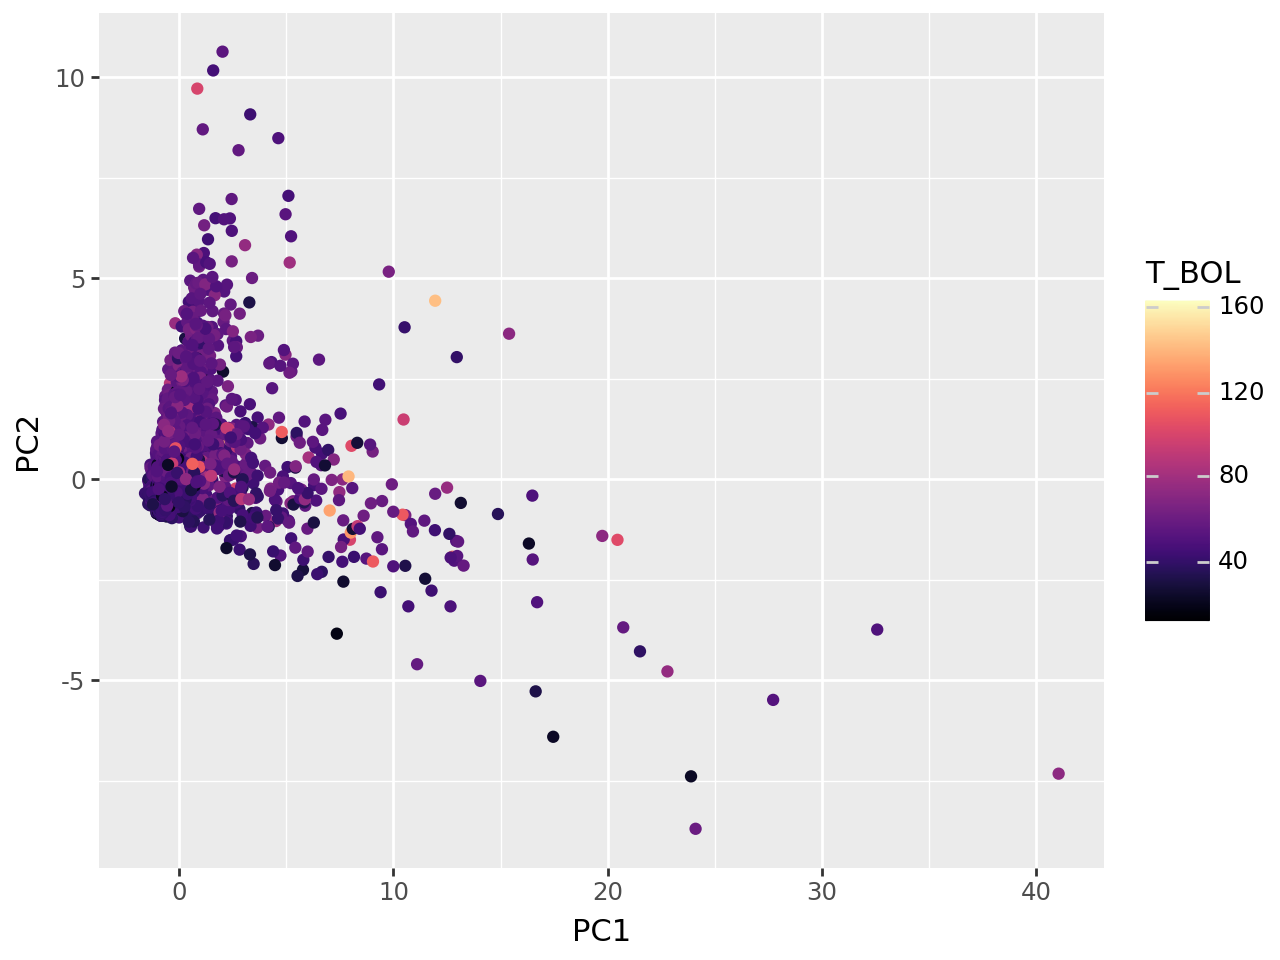

In [109]:
tbol_df = phot_pca_cols.drop(columns=['DIAM', "MASS", "TEMP", "LM", "SURF_DENS", "LRATIO", "L_BOL"])

(
    ggplot(tbol_df, aes(x='PC1', y='PC2', color='T_BOL')) +
    geom_point() +
    scale_color_cmap('magma')
)

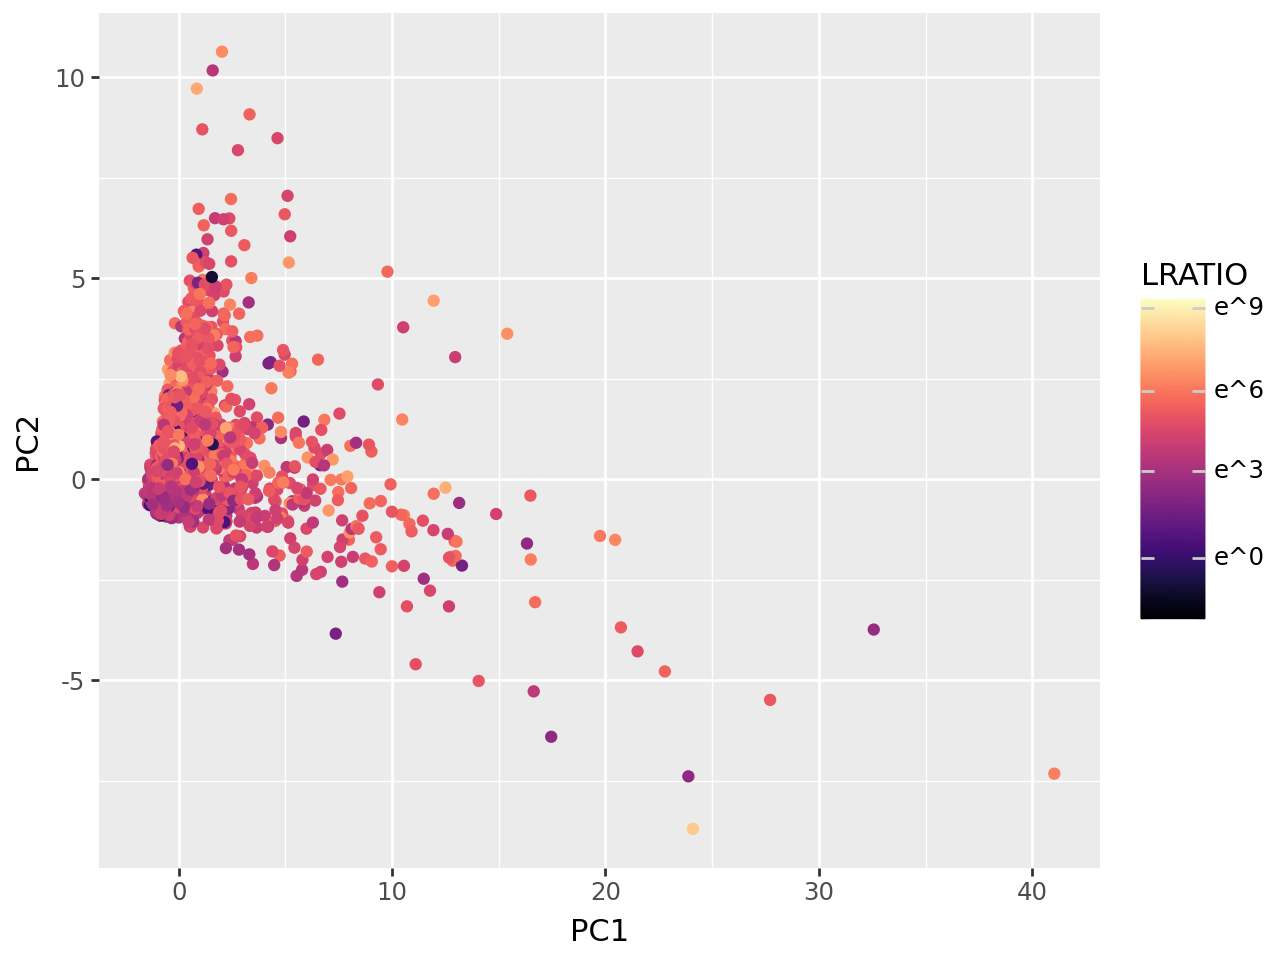

In [111]:
lrat_df = phot_pca_cols.drop(columns=['DIAM', "MASS", "TEMP", "LM", "SURF_DENS", "L_BOL", "T_BOL"])

(
    ggplot(lrat_df, aes(x='PC1', y='PC2', color='LRATIO')) +
    geom_point() +
    scale_color_continuous(trans='log', cmap_name='magma')
)

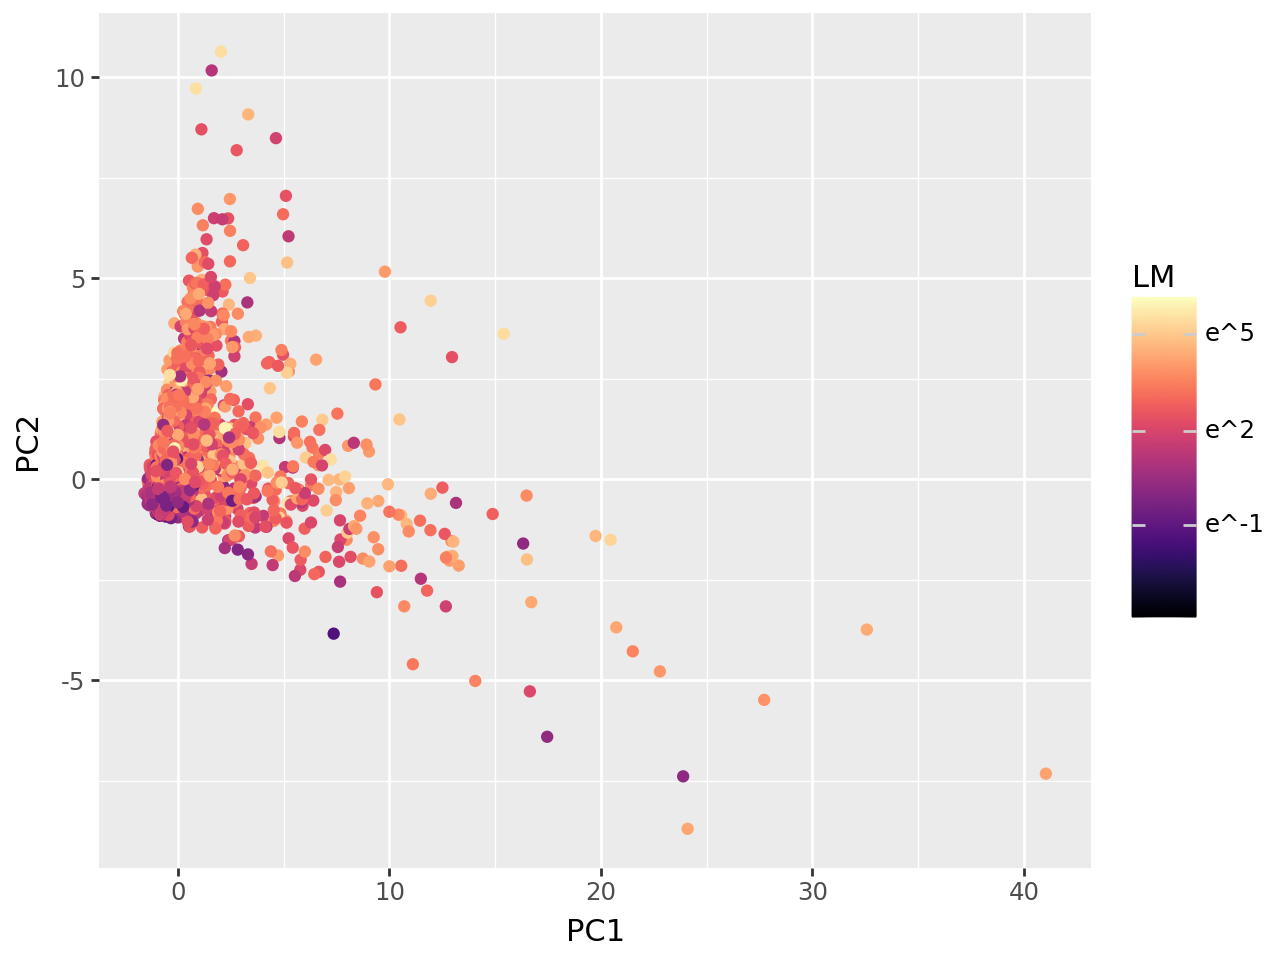

In [113]:
lm_df = phot_pca_cols.drop(columns=['DIAM', "MASS", "TEMP", "LRATIO", "SURF_DENS", "L_BOL", "T_BOL"])

(
    ggplot(lm_df, aes(x='PC1', y='PC2', color='LM')) +
    geom_point() +
    scale_color_continuous(trans='log', cmap_name='magma')
)